PROJECT ON CUSTOMER CHURN USING ML

In [23]:
#CUSTOMER CHURN PROJECT USING ML
import pandas as pd
df=pd.read_csv('custome churn.csv',sep='\t')
df.head()


,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [24]:
df = df.drop('customer_id', axis=1)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tenure            20000 non-null  int64  
 1   monthly_charges   20000 non-null  float64
 2   total_charges     20000 non-null  float64
 3   contract          20000 non-null  str    
 4   payment_method    20000 non-null  str    
 5   internet_service  17987 non-null  str    
 6   tech_support      20000 non-null  str    
 7   online_security   20000 non-null  str    
 8   support_calls     20000 non-null  int64  
 9   churn             20000 non-null  str    
dtypes: float64(2), int64(2), str(6)
memory usage: 1.5 MB


In [26]:
df.isnull().sum().sort_values(ascending=False)

internet_service    2013
tenure                 0
monthly_charges        0
total_charges          0
contract               0
payment_method         0
tech_support           0
online_security        0
support_calls          0
churn                  0
dtype: int64

In [27]:
df['internet_service'].value_counts(dropna=False)

internet_service
Fiber    10064
DSL       7923
NaN       2013
Name: count, dtype: int64

In [28]:
df['churn'].value_counts()

churn
No     13157
Yes     6843
Name: count, dtype: int64

In [29]:
df['churn']=df['churn'].map({'Yes':1,'No':0})

In [30]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
x=df.drop('churn',axis=1)
y=df['churn']
#
num_column=['monthly_charges','total_charges','tenure','support_calls']
cat_column=['contract','payment_method','tech_support','online_security','internet_service']
num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scalar',StandardScaler())
])
cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])
preprocess=ColumnTransformer([
    ('num',num_pipeline,num_column),
    ('cat',cat_pipeline,cat_column)
])
pipe=Pipeline([
    ('preprocessor',preprocess),
    ('model',LogisticRegression())
])
param_grid=[
    {'model':[LogisticRegression(max_iter=200)]
     },
     {
         'model':[RandomForestClassifier()],
         'model__n_estimators':[100,200],
         'model__max_depth':[5,10,13]
     },
     {
         'model':[CatBoostClassifier(verbose=(10))],
         'model__iterations': [200, 500],
        'model__depth': [4, 6],
        'model__learning_rate': [0.03, 0.1,0.4]
     },
]
grid=GridSearchCV(
    pipe,param_grid,cv=5,scoring='accuracy',n_jobs=-1
)
grid.fit(x,y)
print('BEST MODEL:',grid.best_estimator_)
print('BEST PARAMETER:',grid.best_params_)
print('BEST SCORE:',grid.best_score_)

0:	learn: 0.6756748	total: 13ms	remaining: 2.6s
10:	learn: 0.5531210	total: 140ms	remaining: 2.41s
20:	learn: 0.4915131	total: 278ms	remaining: 2.37s
30:	learn: 0.4600026	total: 405ms	remaining: 2.21s
40:	learn: 0.4434476	total: 524ms	remaining: 2.03s
50:	learn: 0.4354290	total: 643ms	remaining: 1.88s
60:	learn: 0.4304087	total: 756ms	remaining: 1.72s
70:	learn: 0.4279158	total: 862ms	remaining: 1.56s
80:	learn: 0.4258497	total: 964ms	remaining: 1.42s
90:	learn: 0.4246943	total: 1.06s	remaining: 1.27s
100:	learn: 0.4237654	total: 1.16s	remaining: 1.14s
110:	learn: 0.4230307	total: 1.27s	remaining: 1.02s
120:	learn: 0.4223029	total: 1.37s	remaining: 894ms
130:	learn: 0.4216122	total: 1.47s	remaining: 772ms
140:	learn: 0.4208317	total: 1.57s	remaining: 656ms
150:	learn: 0.4201906	total: 1.66s	remaining: 539ms
160:	learn: 0.4196569	total: 1.75s	remaining: 425ms
170:	learn: 0.4191496	total: 1.87s	remaining: 317ms
180:	learn: 0.4185045	total: 1.97s	remaining: 207ms
190:	learn: 0.4179010	tot

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
grid.fit(x_train,y_train)
y_pred=grid.predict(x_test)
print('ACCURACY:',accuracy_score(y_pred,y_test))
print('RECALL:',recall_score(y_pred,y_test))

0:	learn: 0.6759266	total: 11.7ms	remaining: 2.33s
10:	learn: 0.5549523	total: 125ms	remaining: 2.15s
20:	learn: 0.4942708	total: 249ms	remaining: 2.13s
30:	learn: 0.4631564	total: 396ms	remaining: 2.16s
40:	learn: 0.4469793	total: 536ms	remaining: 2.08s
50:	learn: 0.4384586	total: 658ms	remaining: 1.92s
60:	learn: 0.4336050	total: 784ms	remaining: 1.79s
70:	learn: 0.4311689	total: 915ms	remaining: 1.66s
80:	learn: 0.4291126	total: 1.03s	remaining: 1.52s
90:	learn: 0.4274815	total: 1.15s	remaining: 1.38s
100:	learn: 0.4264003	total: 1.27s	remaining: 1.24s
110:	learn: 0.4253840	total: 1.38s	remaining: 1.11s
120:	learn: 0.4243623	total: 1.51s	remaining: 988ms
130:	learn: 0.4236259	total: 1.63s	remaining: 860ms
140:	learn: 0.4228849	total: 1.75s	remaining: 735ms
150:	learn: 0.4221080	total: 1.86s	remaining: 605ms
160:	learn: 0.4212566	total: 1.97s	remaining: 478ms
170:	learn: 0.4204772	total: 2.1s	remaining: 355ms
180:	learn: 0.4197234	total: 2.2s	remaining: 231ms
190:	learn: 0.4189758	to

In [33]:
from sklearn.metrics import confusion_matrix
print('confusion matrix:',confusion_matrix(y_test,y_pred))

confusion matrix: [[2495  150]
 [ 425  930]]


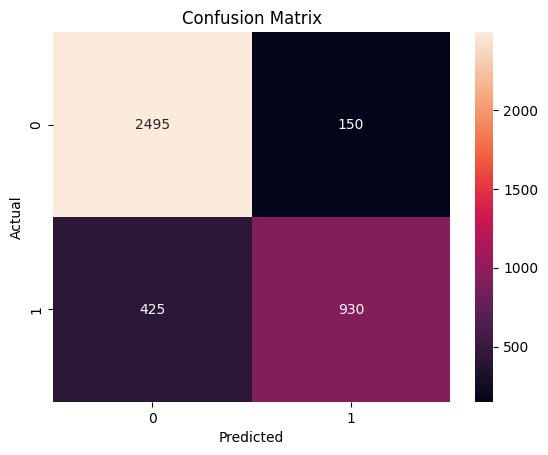

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
import pickle

model = grid.best_estimator_

# save
pickle.dump(model, open('churn_model.pkl', 'wb'))

In [36]:
df.to_csv("custome.csv", index=False)